# 02 · Modelos, calibración y degradación temporal

Qué se responde aquí:

1. ¿Cuál de las tres familias decide mejor, y según qué criterio?
2. ¿Sirve de algo calibrar?
3. ¿Se degrada el sistema estático, y cómo se distingue eso de un cambio de tasa base?

Lee artefactos ya calculados: **no reentrena**.

In [1]:
import sys, json
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "configs").exists() and (ROOT.parent / "configs").exists():
    ROOT = ROOT.parent          # el notebook puede abrirse desde notebooks/
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from fraud_adaptive.pipeline import load_configs
from fraud_adaptive.tracking import read_json

CONFIGS = load_configs(ROOT / "configs")
# La corrida se fija al generar el notebook, de modo que las cifras de aqui son
# las mismas del informe. Dejarla escrita a mano dejaba los notebooks describiendo
# una corrida distinta de la entregada.
RUN_ID = "v3"
RUN_DIR = ROOT / CONFIGS["base"]["paths"]["runs"] / RUN_ID
REPORTS = ROOT / CONFIGS["base"]["paths"]["reports"]

MANIFEST = read_json(ROOT / CONFIGS["base"]["paths"]["manifests"] / "sources.json")
DATA_SOURCE = MANIFEST.get("data_source", "desconocido")

if DATA_SOURCE == "sintetico_sustituto":
    print("AVISO: los datos son un SUSTITUTO SINTETICO. Ninguna cifra describe IEEE-CIS.")
else:
    print("Datos: IEEE-CIS Fraud Detection (particion train).")
print("Run:", RUN_DIR)

Datos: IEEE-CIS Fraud Detection (particion train).
Run: C:\Users\25por\OneDrive\Desktop\utec\planifica\PLANIFICA_PROYECTO01\runs\v3


## 1. Tuning: 18 fits

3 familias × 3 configuraciones × 2 folds forward. La selección es por AP media de validación; los folds son **internos** y sus métricas nunca se reportan como resultado final.

In [2]:
tuning = pd.read_csv(REPORTS / "tables" / "tuning.csv")
tuning.sort_values(["familia", "ap_media"], ascending=[True, False]).round(4)

,familia,config,ap_media,segundos
0,lightgbm,lgbm_31,0.6263,20.890
1,lightgbm,lgbm_15,0.6029,16.310
2,lightgbm,lgbm_31_spw,0.5829,19.672
3,logistic,lr_c1_bal,0.4427,356.212
4,logistic,lr_c01,0.4296,334.696
5,logistic,lr_c1,0.4296,337.058
6,random_forest,rf_200_20,0.5287,35.687
7,random_forest,rf_100_12,0.5016,18.578
8,random_forest,rf_200_12,0.4902,29.149


## 2. Comparación de las tres familias

El criterio de decisión es el **costo**, no el AP. Una familia con mejor AP puede decidir peor si su calibración está sesgada, porque la política compara costos esperados y esos costos se calculan con `p`.

La columna `costo_um_tx_umbral_fijo` es el costo que alcanzaría el mejor par de umbrales globales sobre `p`. La diferencia con `costo_um_tx_politica` mide lo que cuesta ignorar el monto.

In [3]:
modelos = pd.read_csv(REPORTS / "tables" / "comparacion_modelos.csv")
modelos[["familia", "config", "ap_politica", "costo_um_tx_politica",
         "brier_crudo", "brier_calibrado", "ece_crudo", "ece_calibrado",
         "costo_um_tx_umbral_fijo", "regla", "elegida_para_adaptacion"]].round(5)

,familia,config,ap_politica,costo_um_tx_politica,brier_crudo,brier_calibrado,ece_crudo,ece_calibrado,costo_um_tx_umbral_fijo,regla,elegida_para_adaptacion
0,lightgbm,lgbm_31,0.62137,1.58950,0.01997,0.01982,0.00375,0.00149,1.96961,argmin,True
1,random_forest,rf_200_20,0.53914,1.87279,0.05250,0.02524,0.14248,0.00514,2.27457,argmin,False
2,logistic,lr_c1_bal,0.40293,2.19096,0.14214,0.03111,0.28501,0.00440,2.87118,argmin,False


### Por qué calibrar

La política compara `p·monto` con `(1−p)·c_FP`. Esa aritmética solo tiene sentido si
`p` es una probabilidad, no un puntaje ordenado. Un modelo con `scale_pos_weight`
produce puntajes inflados: usarlos como probabilidad haría bloquear de más, y el
AP no lo notaría.

In [4]:
estaticos = read_json(RUN_DIR / "static_results.json")

for familia, info in estaticos["familias"].items():
    cal = info["calibracion"]
    print(f"{familia:<15} Brier {cal['brier_crudo']:.5f} -> {cal['brier_calibrado']:.5f}"
          f"   ECE {cal['ece_crudo']:.5f} -> {cal['ece_calibrado']:.5f}")

print(f"\nFamilia congelada para adaptación: {estaticos['familia_elegida']}")
print(f"Hash de prerregistro: {estaticos['prerregistro']['hash'][:32]}")

logistic        Brier 0.14214 -> 0.03111   ECE 0.28501 -> 0.00440
random_forest   Brier 0.05250 -> 0.02524   ECE 0.14248 -> 0.00514
lightgbm        Brier 0.01997 -> 0.01982   ECE 0.00375 -> 0.00149

Familia congelada para adaptación: lightgbm
Hash de prerregistro: 7d4c9fac0af4d15f519f82be803aedcb


## 3. La política: argmin económico, no umbrales

La acción es el mínimo de los tres costos esperados, caso por caso. No hay cortes
sobre `p` que decidan.

El motivo es que el punto de indiferencia entre aprobar y bloquear es
`p* = c_FP / (monto + c_FP)`, de modo que depende del monto. Un corte fijo bloquea
de más en los montos bajos y de menos en los altos.

`c_FP` tampoco se fija a mano. No es observable, pero la fracción de legítimas
rechazadas sí lo es y es lo que la operación restringe. Se declara el objetivo y se
busca el menor `c_FP` que lo cumple.

In [5]:
elegida = estaticos["familias"][estaticos["familia_elegida"]]

print("Política:", json.dumps(elegida["policy"], indent=2))
print("Economía congelada:", json.dumps(estaticos["costos"], indent=2))

cal = estaticos["calibracion_c_fp"]
print(f"\nc_FP calibrado contra un objetivo de bloqueo de legítimas del "
      f"{cal['objetivo']:.1%}")
print(f"   familia de referencia : {cal['familia_referencia']}")
print(f"   valor elegido         : {cal['c_fp']:.1f}")
print(f"   tasa alcanzada        : {cal['tasa_bloqueo_legitimo']:.4f}")
pd.DataFrame(cal["tabla"]).round(5)

Política: {
  "rule": "argmin",
  "tau_low": 0.0,
  "tau_high": 1.0,
  "daily_capacity": 150,
  "delta": 0.0,
  "review_price": 7.864817550115768,
  "version": "politica_v3"
}
Economía congelada: {
  "c_fp": 25.0,
  "c_review": 1.0,
  "r_h": 0.9,
  "f_h": 0.02
}

c_FP calibrado contra un objetivo de bloqueo de legítimas del 1.0%
   familia de referencia : lightgbm
   valor elegido         : 25.0
   tasa alcanzada        : 0.0089


,c_fp,tasa_bloqueo_legitimo,n_revisiones,monto_fraude_aprobado,cumple_objetivo
0,5.0,0.11172,0,11764.587,False
1,10.0,0.05996,0,22047.520,False
2,15.0,0.01724,820,24297.156,False
3,20.0,0.01139,941,25635.335,False
4,25.0,0.00888,970,26301.396,True
5,30.0,0.00768,985,26804.328,True
6,40.0,0.00601,1003,27796.061,True
7,50.0,0.00460,1004,28374.425,True
8,60.0,0.00397,1007,28374.425,True
9,75.0,0.00313,1007,28988.837,True


In [6]:
print("El argmin induce un umbral distinto por monto:")
for u in estaticos["umbrales_implicados"]:
    print(f"   monto {u['monto']:8.2f} -> revisar desde p={u['tau_low']:.4f},"
          f" bloquear desde p={u['tau_high']:.4f}")

print(f"\nCosto con argmin          : {elegida['costo_politica']:.4f} UM/tx")
print(f"Costo con el mejor umbral fijo: {elegida['costo_umbral']:.4f} UM/tx")

print("\nUmbral para FPR<=1%   :", json.dumps(elegida["umbral_fpr"], indent=2))
print("Umbral para precisión>=80%:", json.dumps(elegida["umbral_precision"], indent=2))
print("\nReferencias simuladas (UM/tx):")
for nombre, valores in estaticos["baselines"].items():
    print(f"   {nombre:<18} {valores['costo_por_tx']:.4f}")

El argmin induce un umbral distinto por monto:
   monto    25.00 -> revisar desde p=0.4072, bloquear desde p=0.5791
   monto    59.00 -> revisar desde p=0.1747, bloquear desde p=0.5143
   monto   250.00 -> revisar desde p=0.0415, bloquear desde p=0.3159

Costo con argmin          : 1.5895 UM/tx
Costo con el mejor umbral fijo: 1.9696 UM/tx

Umbral para FPR<=1%   : {
  "umbral": 0.2939807353178769,
  "fpr_en_validacion": 0.009975974093805495,
  "objetivo_fpr": 0.01
}
Umbral para precisión>=80%: {
  "umbral": 0.5817804834769602,
  "precision_en_validacion": 0.8015873015873016,
  "objetivo_precision": 0.8
}

Referencias simuladas (UM/tx):
   aprobar_todo       4.5937
   bloquear_todo      24.1365


## 4. Degradación del sistema estático

La evidencia clave no es que el AP baje, sino que baje **mientras la tasa base se
mantiene plana**. Si la prevalencia cayera a la vez, el AP bajaría por aritmética y
no habría nada que concluir sobre el modelo.

In [7]:
from fraud_adaptive.metrics import metrics_by_period

desenlaces = pd.read_parquet(RUN_DIR / "outcomes.parquet")
estatico = desenlaces[desenlaces["estrategia"] == "S0"]

serie = metrics_by_period(estatico, period_column="semana",
                          threshold_binary=elegida["umbral_fpr"]["umbral"])
serie[["semana", "n", "prevalencia", "ap", "skill", "brier", "costo_por_tx"]].round(4)

,semana,n,prevalencia,ap,skill,brier,costo_por_tx
0,17,19634,0.0332,0.6026,0.5889,0.0184,2.0900
1,18,19258,0.0378,0.4462,0.4244,0.0269,2.4377
2,19,18572,0.0329,0.4546,0.4361,0.0228,1.8882
3,20,18549,0.0344,0.3832,0.3611,0.0263,2.5029
4,21,21443,0.0308,0.4874,0.4711,0.0205,2.1238
5,22,19811,0.0285,0.4414,0.4250,0.0208,1.7816
6,23,21038,0.0347,0.4469,0.4270,0.0251,1.7750
7,24,19941,0.0368,0.5370,0.5194,0.0232,1.9854
8,25,17752,0.0421,0.5236,0.5027,0.0267,2.3071


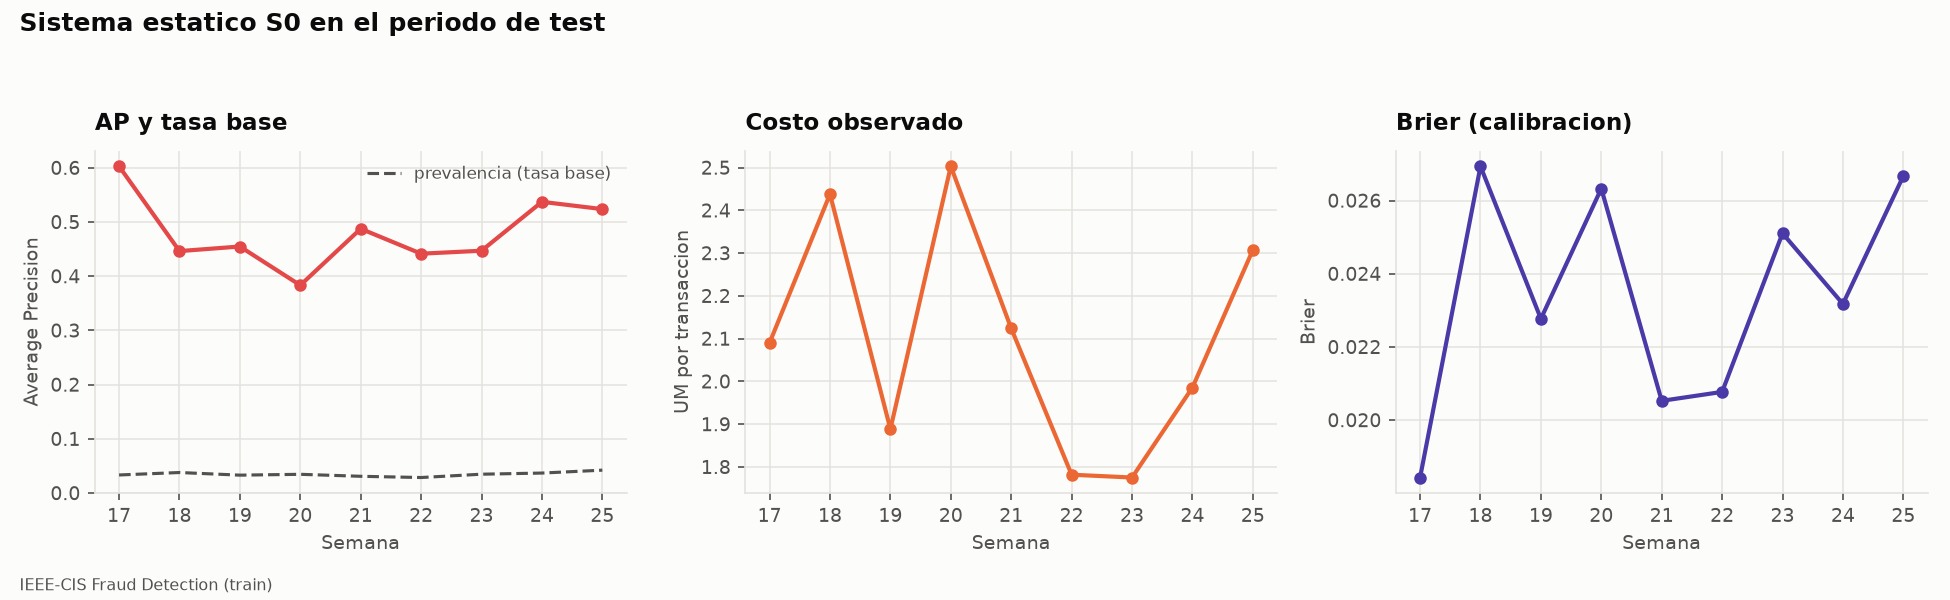

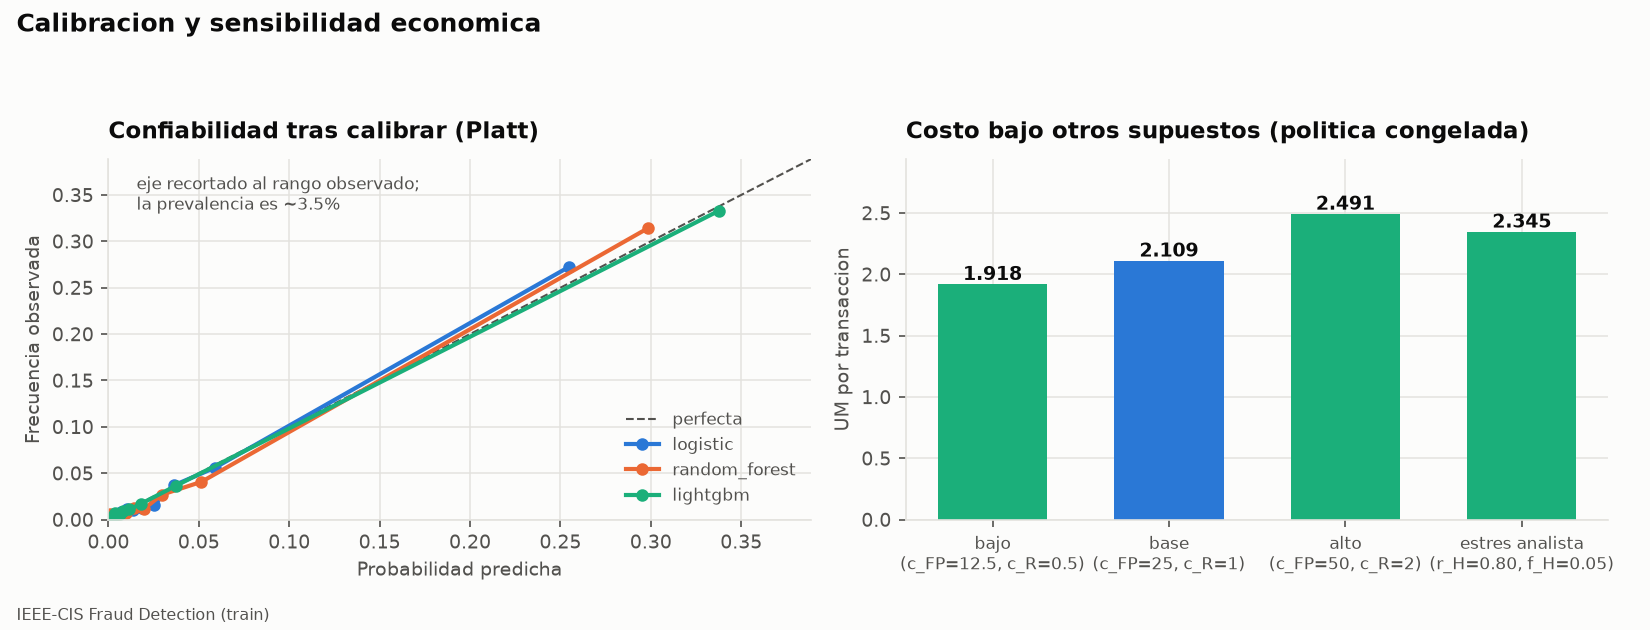

In [8]:
from IPython.display import Image, display
display(Image(filename=str(REPORTS / "figures" / "rendimiento_estatico.png")))
display(Image(filename=str(REPORTS / "figures" / "calibracion_costos.png")))

## 5. Lectura

Si el AP cae y la prevalencia no, el modelo perdió capacidad discriminante sobre
las mismas clases: es consistente con un cambio en P(y|X). La comparación temporal
por sí sola **no identifica causalmente** el drift, y el informe no lo afirma.